# EXPLORATORY DATA ANALYSIS WITH TARGET VARIABLE

In [4]:
#for data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import scipy.stats as stats

#for outliers
from statsmodels.stats.outliers_influence import variance_inflation_factor

### FUNCTIONS DEFINITION

- Correlation between target variable and explanatory ones

In [40]:
def plot_correlation_with_target(df, target_variable):
    """
    Plots a correlation matrix of all variables in the dataframe with the target variable.
    
    Parameters:
    df (pd.DataFrame): The input dataframe
    target_variable (str): The target variable
    """
    # Compute correlation matrix
    correlation_matrix = df.corr()[[target_variable]].sort_values(by=target_variable, ascending=False)

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation of Features with {target_variable}")
    plt.show()

### EDA - Exploratory Data Analysis

To begin with, the enginereed dataset is loaded.

In [6]:
#load fe dataset
df = pd.read_csv("../data/crypto_volatility_fe_ewm.csv")
#create a copy
df3 = df.copy()
#show it
df.head(5)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5,volatility
0,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378,0.074001
1,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621,0.047295
2,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290,0.058076
3,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932,0.063501
4,2018-02-11,8063.88,45025.187952,25,31.0,4,-0.056661,822.47,279.86,-4356.324701,0.062370,0.069856


And split the dataset into Xs and y (volatility).

In [7]:
#define y
y = df["volatility"]
#define x
x = df.copy() #create a df copy
x = x.drop(columns = ["volatility"])

#show it
x.head(5)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378
1,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621
2,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290
3,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932
4,2018-02-11,8063.88,45025.187952,25,31.0,4,-0.056661,822.47,279.86,-4356.324701,0.062370


Let's display how volatility changed over time.

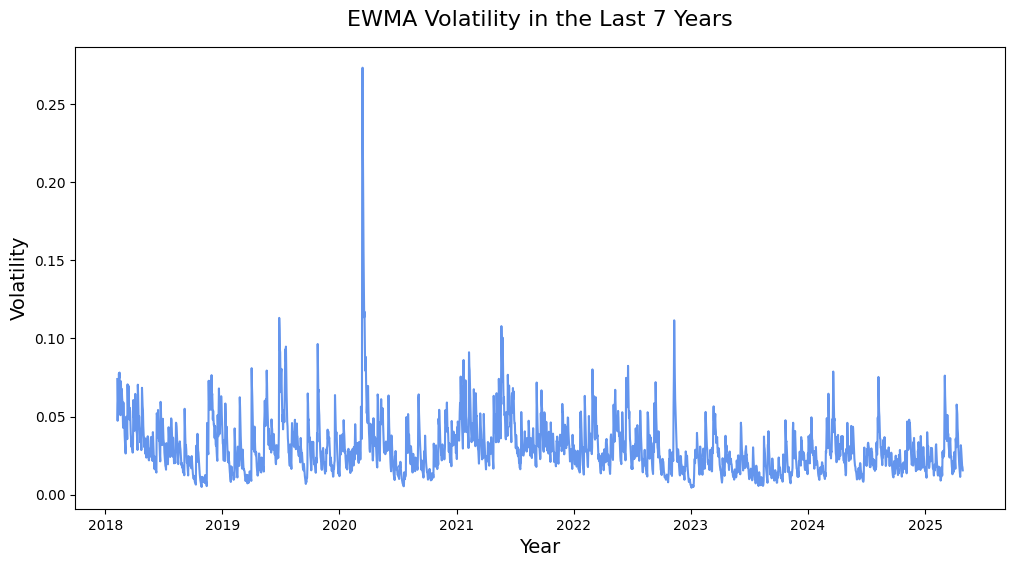

In [8]:
# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='volatility', data=df, color = "cornflowerblue")
# Format x-axis to show only years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Show tick per year

# Add axis labels and title
plt.xlabel("Year", fontsize=14)
plt.ylabel("Volatility", fontsize=14)
plt.title("EWMA Volatility in the Last 7 Years", fontsize=16, pad=15)

# Save the figure
plt.savefig("../img/volatility.png", bbox_inches="tight", dpi=300)

# Show the plot
plt.show()

At first glance, it's clear that Bitcoin's volatility has experienced continuous ups and downs, highlighting how investor sentiment in crypto swings easily. Yet, almost all peaks and troughs remain within the 0 to 0.10 range, indicating a certain degree of volatility consistency over time.  
  
Particularly interesting is the sharp spike in volatility during the early months of 2020 — the onset of the COVID-19 pandemic and widespread lockdowns. As people were forced to stay home, their attention increasingly shifted toward digital assets like cryptocurrencies. Therefore, the volatility peak at the beginning of 2020 seems both notable and reasonable.  
  
Let’s zoom in on this period for a closer look.

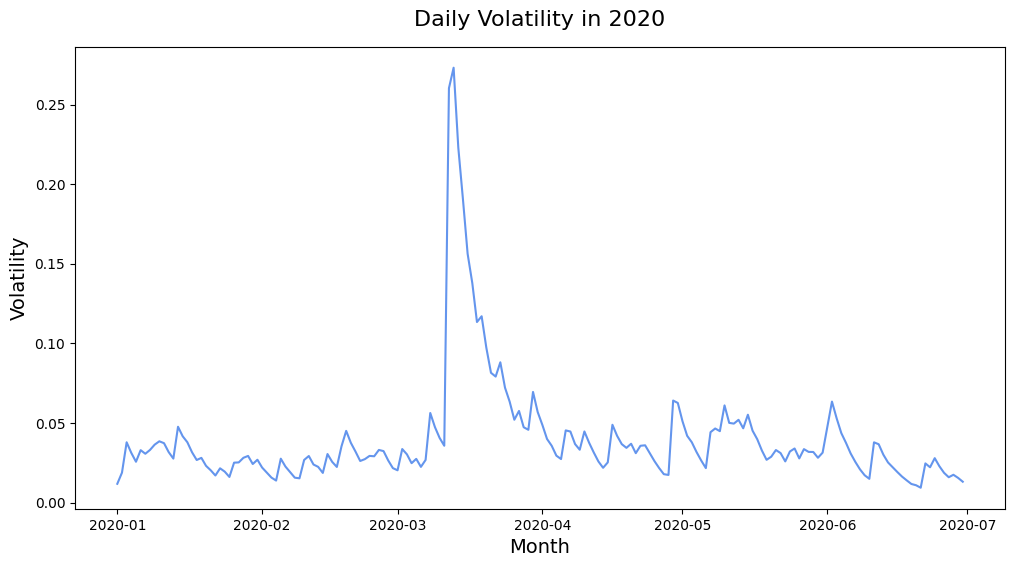

In [9]:
#define the start and ending date
start_date = "2020-01-01"
end_date = "2020-07-01"

# Filter data between two dates
filtered_df = df.loc[(df['date'] >= start_date)
                     & (df['date'] < end_date)]

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='volatility', data=filtered_df, color = "cornflowerblue")
# Add axis labels and title
plt.xlabel("Month", fontsize=14)
plt.ylabel("Volatility", fontsize=14)
plt.title("Daily Volatility in 2020", fontsize=16, pad=15)
# Show the plot
plt.show()

In [10]:
#check the max
df.iloc[df['volatility'].idxmax()]

date             2020-03-13 00:00:00
close                         5578.6
volume                 402201.673764
trend                            100
fg_index                        10.0
cluster                            2
log_return                  0.150322
hl_spread                    2172.87
momentum_3                  -2315.96
vol_change             140696.065111
rolling_std_5               0.249414
volatility                  0.273232
Name: 765, dtype: object

Zooming in on 2020, it is revealed that the volatility spike occurred primarily during the first days of March. This sharp increase was the result of a brief but intense period for crypto markets, driven by a combination of impactful global events:  
  
- Black Thursday: A global market crash triggered by the official declaration of COVID-19 as a pandemic. Panic spread across all asset classes, including crypto.
- Mass Liquidations: Bitcoin’s price dropped by over 40% in a single day due to cascading liquidations. This magnified the sell-off and drove volatility to extreme levels.
- Dash for Cash: As investors rushed to cover losses and increase liquidity, many sold off riskier assets like cryptocurrencies to hoard cash.
- Market Sentiment: Although crypto is decentralized, it remained tied to broader market sentiment, reacting to global uncertainty like traditional markets.  
  
These few days, while appearing as outliers, reflect real and significant market behavior. For this reason, they will not be discarded. On the contrary, keeping them will enhance the model’s ability to recognize and learn from extreme events — an essential capability in volatility forecasting.


Turning to Volatility's distribution, let's show it.

Text(0.5, 1.0, 'Volatility Distribution')

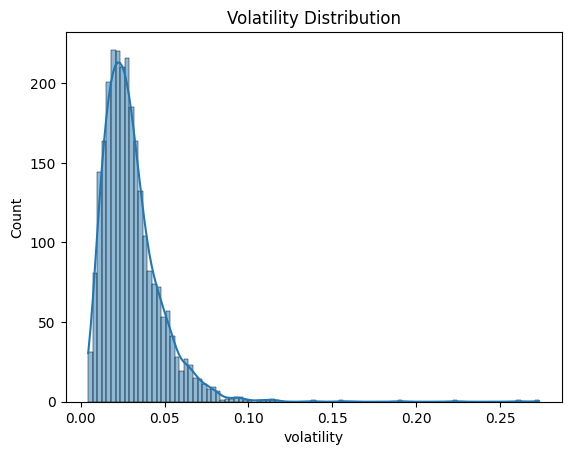

In [11]:
#show volatility distribution 
sns.histplot(df['volatility'], kde=True )
plt.title("Volatility Distribution")

The plot shows a right-skewed distribution of volatility values, with most observations concentrated between 0.01 and 0.05. The distribution peaks around 0.02–0.03, indicating that low volatility is most common in the dataset. A long tail extends to the right, showing a few instances of much higher volatility. This pattern suggests that while stable conditions dominate, occasional spikes in volatility occur.

### Target Variable & regressors relations

Shifting focus, it is a good idea to examine pairwise relations between Volatility and the regressors.

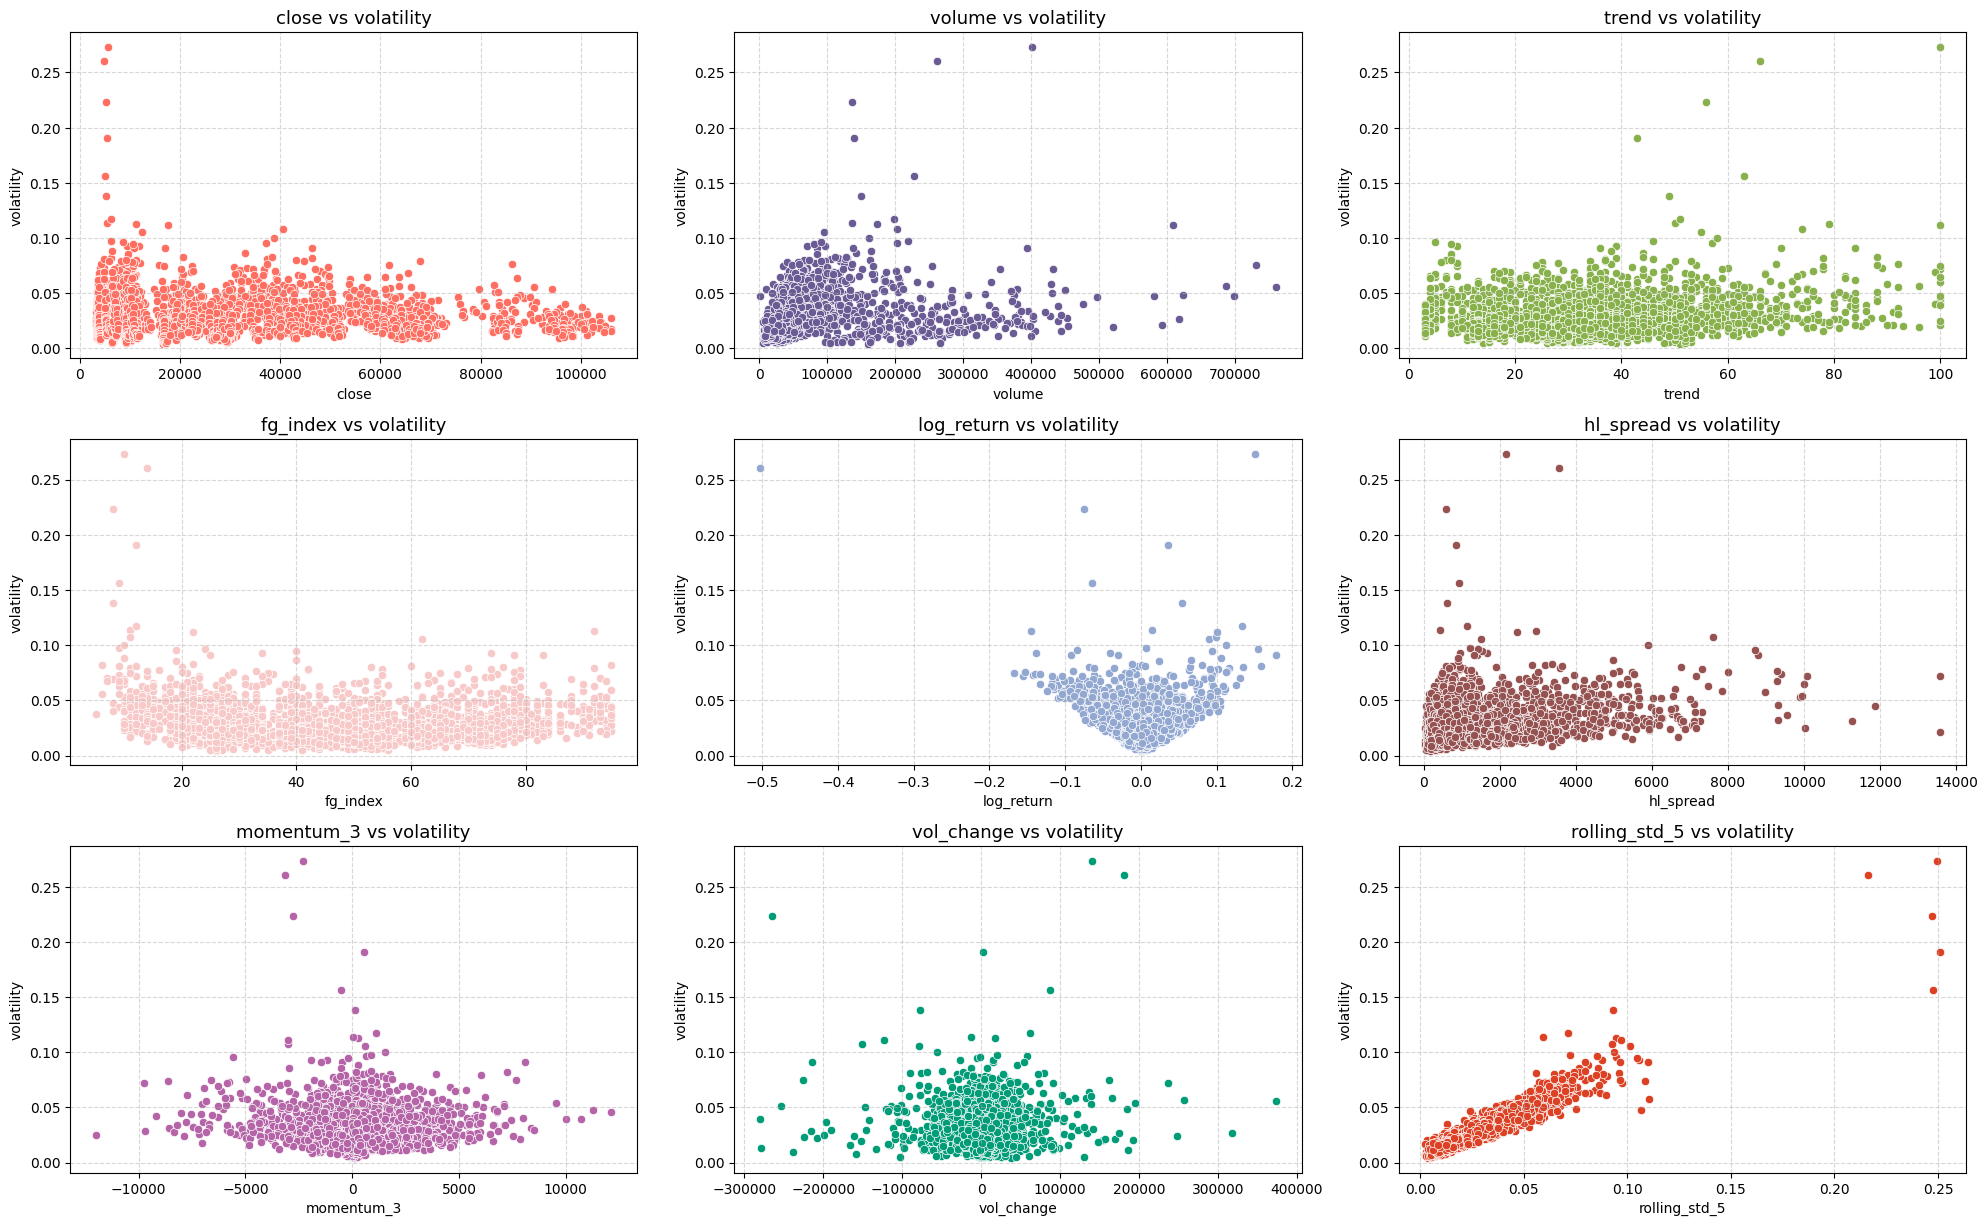

<Figure size 640x480 with 0 Axes>

In [ ]:
# Assuming 'variables' is your list of 10 features (excluding 'date')
variables = df.columns.tolist()
variables.remove('date')
variables.remove('volatility')
variables.remove('cluster')

#define colors
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1',
          '#955251', '#B565A7', '#009B77', '#DD4124']

# Set up a 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
#fig.suptitle("Scatterplots: Features vs hl_spread", fontsize=20, y=0.93)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through variables
for i, var in enumerate(variables):
    sns.scatterplot(data=df, x=var, y='volatility', ax=axes[i], color=colors[i % len(colors)])
    axes[i].set_title(f"{var} vs volatility", fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("volatility")
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove any unused subplots (in your case, 2)
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#save it
plt.savefig("../img/scatterPlots.png", bbox_inches="tight", dpi=300)

At first glance, several features — including close, fg_index, momentum_3, and trend — do not display a clear or consistent relationship with volatility. The data points for these variables appear widely scattered, forming horizontal clouds that suggest no evident directional pattern or strong association with the volatility target.  
  
Features such as volume, hl_spread, and vol_change exhibit more variation in their distributions, yet still lack a distinct trend in relation to volatility. While there is some concentration of points in lower volatility regions, these features do not show a clear monotonic or curvilinear relationship.  
  
The variable log_return forms a more structured V-shaped distribution, indicating that extreme positive or negative returns are associated with higher volatility. This symmetry around zero suggests a potential nonlinear relationship worth further exploration.  
  
Notably, rolling_std_5 is the only feature demonstrating a visible and approximately linear positive association with volatility. As the 5-day rolling standard deviation increases, so does the observed volatility, implying that this feature may hold genuine explanatory power in modeling or predicting volatility.  
  
In summary, most features remain weakly or non-related to volatility, with log_return suggesting a nonlinear link and rolling_std_5 standing out as the most correlated feature.

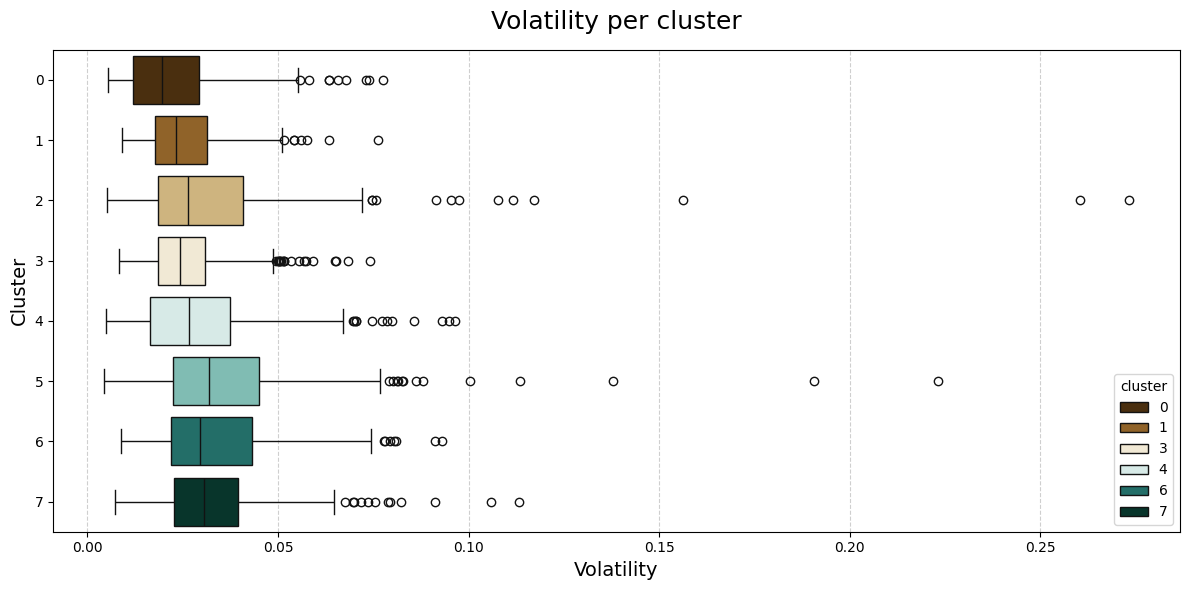

In [48]:
#boxplots for cluster
plt.figure(figsize=(12, 6))
# Create the boxplot
sns.boxplot(data=df, x='volatility', y='cluster', orient='h', hue = "cluster", palette='BrBG')
# Title and labels
plt.title("Volatility per cluster", fontsize=18, pad=15)
plt.xlabel("Volatility", fontsize=14)
plt.ylabel("Cluster", fontsize=14)
# Improve layout#
plt.grid(axis="x", linestyle="--", alpha=0.6)  # Add a light grid for readability
plt.tight_layout()
#save it
plt.savefig("../img/ClusterVolatility.png", bbox_inches="tight", dpi=300)
# Show the plot
plt.show()

Regarding cluster, clusters 2, 5, 6, and 7 show slightly elevated volatility levels, with clusters 2 and 5 containing most of the extreme outliers. However, the clusters do not reveal a strong or consistent differentiation in volatility, indicating that the grouping has limited predictive power for this target.  

### Regressors & target variable correlation

To conclude, data leak must be considered. Data leak could biases any predictive model's results. As a consequence, it must be throughly considered and, if necessary, tackled.
   
To prevent data leak, the first step is to ensure that none of the regressor is highly correlated with the target variable.
  
Note that, as the dataset is already enginereed, there should not be concerns about correlation.

In [49]:
df2 = df.drop(columns = ['date'])
#compute the entire correlation matrix
volcorr = df2.corr()
#filter just for the column left
volcorr = volcorr["volatility"].drop("volatility")
#print it
print("Correlation between Left and various regressors:")
volcorr

Correlation between Left and various regressors:


close           -0.087768
volume           0.226395
trend            0.209698
fg_index        -0.124322
cluster          0.189989
log_return      -0.042569
hl_spread        0.279623
momentum_3      -0.037905
vol_change       0.020861
rolling_std_5    0.940536
Name: volatility, dtype: float64

Shown in a heatmap.

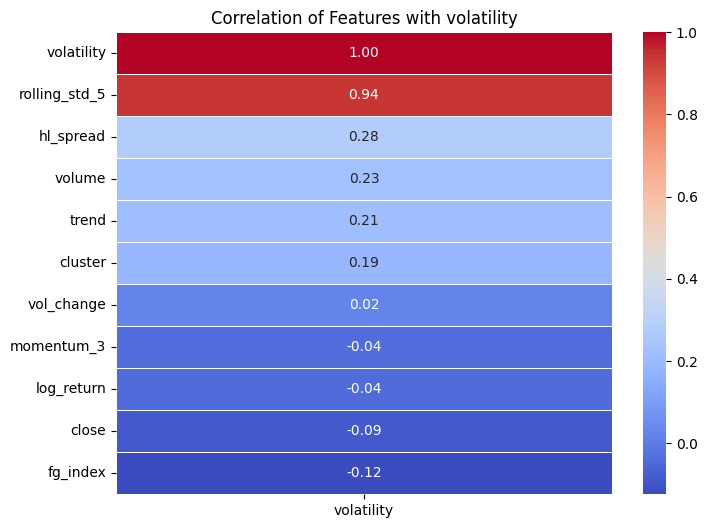

In [50]:
df2 = df.drop(columns = ['date'])
plot_correlation_with_target(df2, "volatility")

The correlation results confirm much of what the scatter plots suggested:  
  
- rolling_std_5 shows an exceptionally strong positive correlation with volatility (0.94), indicating an almost linear relationship. This aligns with the tight upward-sloping pattern seen in its scatter plot.
- hl_spread (0.28), volume (0.23), trend (0.21), and cluster (0.19) show moderate positive correlations. These features may capture structural or market-related dynamics that co-move with volatility, albeit to a much lesser extent than rolling_std_5.
- fg_index has a mild negative correlation (-0.12), suggesting that higher fear & greed sentiment is weakly associated with lower volatility — a plausible narrative in crypto markets.
- close, log_return, momentum_3, and vol_change have correlations close to zero, reinforcing the idea that they provide little linear explanatory power for volatility in this context.  

The high correlation between Y and rollign_std_5 could be an issue during the model procedure.   
  
Since both variables are derived from the same underlying series and capture nearly identical information using different smoothing techniques, including rolling_std_5 would introduce redundancy and risk skewing model results without adding meaningful predictive value. Therefore, rolling_std_5 will be dropped in order to avoid redundancy.
  
In order to avoid redundancy, the latter will be dropped. 

In [51]:
## scaled data
# List of scaled dataset filenames 
dataset_files = [
    "X_tr_scal_ewm.csv",
    "X_val_scal_ewm.csv",
    "X_tt_scal_ewm.csv"
]
#define the saving directory
path = "../data/scaled_data/"

#set a loop to to drop rolling_std_5 in all the scaled datasets
for file_name in dataset_files:
    #read the df
    df = pd.read_csv(path + file_name, index_col=0)  # index_col=0 to preserve original index
    #drop rolling_std_5 if exists
    if 'rolling_std_5' in df.columns:
        df = df.drop(columns=['rolling_std_5'])
    #add no STd to differentiate the sets
    new_file_name = file_name.replace(".csv", "_noStd.csv")
    df.to_csv(path + new_file_name, index=True)    

In [52]:
## unscaled data
dataset_files_unscaled = [
    "X_tr_ewm.csv",
    "X_val_ewm.csv",
    "X_tt_ewm.csv"
]
#define the path
path_unscaled = "../data/unscaled_data/"
#set a loop to to drop rolling_std_5 in all the unscaled datasets
for file_name in dataset_files_unscaled:
    #read the df
    df = pd.read_csv(path_unscaled + file_name, index_col=0)  # index_col=0 to preserve original index
    #drop rolling_std_5 if exists
    if 'rolling_std_5' in df.columns:
        df = df.drop(columns=['rolling_std_5'])
    #add no STd to differentiate the sets
    new_file_name = file_name.replace(".csv", "_noStd.csv")
    df.to_csv(path_unscaled + new_file_name, index=True)

Let's confirm the dataframes have been properly saved.

In [53]:
#check the df
try_scal = pd.read_csv(path + "X_tr_scal_ewm_noStd.csv", index_col=0)
try_scal.head()

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change
0,2018-02-07,-0.712976,0.168652,1.116642,-0.367605,0,-0.199027,0.070480,-0.356471,-1.459462
1,2018-02-08,-0.702790,-1.540343,0.657685,-0.632067,0,0.587014,-0.644364,0.452789,-2.193600
2,2018-02-09,-0.653246,-0.993489,0.313466,-0.014990,0,2.749266,-0.185793,0.559051,0.701597
3,2018-02-10,-0.661501,-0.160041,-0.088122,0.425780,0,-0.463748,-0.187367,0.504264,1.069417
4,2018-02-11,-0.687382,-0.285679,-0.260231,-0.587990,4,-1.458020,-0.270992,0.133480,-0.161491


To conlude, let's save the entire dataframe without rolling_std_5.

In [55]:
df3 = df3.drop(columns=['rolling_std_5'])
df3.to_csv("../data/crypto_volatility_fe_ewm_noSTD.csv", index = True)